# DAY 2 · ESS 배터리 수명 예측 — 모델 개발 및 평가
**울산캠퍼스 2반 · 손민재** · 학습 Batch 1 → 테스트 Batch 2 (+ Batch 3) · Target `cycle_life` → 모델은 `log10(cycle_life)` 예측, 평가 MAPE(사이클 수 기준)

| 섹션 | 내용 |
|---|---|
| 0 | 환경 설정 · 데이터 로딩 · 전처리 · 피처 |
| 1 | 모델·피처 세트 정의 |
| 2 | 데이터 분할 · 하이퍼파라미터 튜닝 · 후보 비교 |
| 3 | 최종 모델 · 성능 (Notion 형식) |
| 4 | 피처 세트 비교 (SVR 기준) · 선형성 |
| 5 | 오류 분석 |
| 6 | 과적합 점검 |
| 7 | 원논문 분할 방식 재현 · 평가 방식별 모델 비교 |

## 0. 환경 설정 · 데이터 · 전처리 · 피처

In [1]:
import os, re, json, pickle, warnings
import numpy as np, pandas as pd, h5py
import matplotlib.pyplot as plt
from itertools import product
from scipy import stats
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.cross_decomposition import PLSRegression
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel as Ck, RBF, WhiteKernel
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
warnings.filterwarnings('ignore')
plt.rcParams.update({'font.family': 'Apple SD Gothic Neo', 'axes.unicode_minus': False, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': .25})
pd.set_option('display.width', 220, 'display.max_columns', 30)

ROOT = os.getcwd() if os.path.isdir(os.path.join(os.getcwd(), 'data')) else os.path.expanduser('~/Downloads/miniproject')
DATA_DIR, CACHE_DIR, RESULT_DIR = [os.path.join(ROOT, d) for d in ('data/archive', 'cache', 'results')]
for d in (CACHE_DIR, RESULT_DIR): os.makedirs(d, exist_ok=True)
FILES = {'B1': '2017-05-12_batchdata_updated_struct_errorcorrect.mat',
         'B2': '2018-02-20_batchdata_updated_struct_errorcorrect.mat',
         'B3': '2018-04-12_batchdata_updated_struct_errorcorrect.mat'}
EOL, SEED, TARGET_PAPER = 0.88, 0, 9.1
NQ = 150   # 보관할 Qdlin 사이클 수 (cycle 100 이전만 사용)

In [2]:
def _txt(f, ref):
    a = np.array(f[ref][()]).flatten()
    if a.dtype.kind not in 'iu' or a.size == 0 or a.max() > 0x10FFFF: return ''
    return ''.join(chr(int(c)) for c in a)

def extract(tag):
    with h5py.File(os.path.join(DATA_DIR, FILES[tag]), 'r') as f:
        b = f['batch']; vdlin = np.array(f[b['Vdlin'][0, 0]][()]).flatten(); cells = []
        for i in range(b['summary'].shape[0]):
            s = f[b['summary'][i, 0]]; cyc = f[b['cycles'][i, 0]]; nc = cyc['Qdlin'].shape[0]
            qd = [np.array(f[cyc['Qdlin'][j, 0]][()]).flatten() for j in range(min(NQ, nc))]
            qd = [a if a.size == vdlin.size else np.full(vdlin.size, np.nan) for a in qd]
            cells.append(dict(batch=tag, idx=i, name=f'{tag}c{i}', n_cycles=nc,
                              cycle_life=float(np.array(f[b['cycle_life'][i, 0]][()]).flatten()[0]), policy=_txt(f, b['policy_readable'][i, 0]),
                              summary={k: np.array(s[k][()]).flatten() for k in s.keys()}, Qdlin=np.array(qd, dtype=np.float32)))
    return dict(vdlin=vdlin, cells=cells)

cells = []
for tag in FILES:
    p = os.path.join(CACHE_DIR, f'{tag}.pkl')
    if not os.path.exists(p): pickle.dump(extract(tag), open(p, 'wb'))
    cells += pickle.load(open(p, 'rb'))['cells']
print({t: sum(c['batch'] == t for c in cells) for t in FILES}, '셀 로딩')

{'B1': 46, 'B2': 47, 'B3': 46} 셀 로딩


In [3]:
# ---- 전처리: Target 값 점검 · 스파이크 보정 · 피처 계산 (초기 100 cycle 데이터만) ----
SPIKE_TOL = 0.02
def status(c):
    if np.isnan(c['cycle_life']): return 'no_label'
    q = c['summary']['QDischarge']; q = q[q > 0.5]
    return 'valid' if q[-1] <= EOL + 0.005 else 'censored'          # EOL 미도달 셀 제외

def clean_qd(c):
    s = c['summary']; cyc = s['cycle'].astype(int); q = s['QDischarge'].astype(float).copy()
    q[(q < 0.5) | (q > 1.3)] = np.nan
    rm = pd.Series(q).rolling(11, center=True, min_periods=3).median().values
    q[np.abs(q - rm) > SPIKE_TOL] = np.nan
    return cyc, pd.Series(q).interpolate(limit_direction='both').values

def features(c, n=100):
    s = c['summary']; cyc, qd = clean_qd(c); m = (cyc >= 2) & (cyc <= n)
    dq = (c['Qdlin'][n - 1] - c['Qdlin'][9]).astype(float); d = dq[np.isfinite(dq)]       # ΔQ(V) = Q(cycle 100) - Q(cycle 10)
    ir = np.where(s['IR'] > 0, s['IR'].astype(float), np.nan)
    return {'dq_var': np.log10(abs(np.var(d))), 'dq_min': np.log10(abs(d.min())), 'dq_mean': np.log10(abs(d.mean())),
            'dq_skew': np.log10(abs(stats.skew(d))), 'dq_kurt': np.log10(abs(stats.kurtosis(d))),
            'qd_2': qd[1], 'qd_100': qd[n - 1], 'qd_slope_2_100': np.polyfit(cyc[m], qd[m], 1)[0],
            'ir_mean': np.nanmedian(ir[1:n]), 'ct_mean': np.nanmedian(s['chargetime'][1:n])}

rows = []
for c in cells:
    rows.append(dict(cell=c['name'], batch=c['batch'], cycle_life=c['cycle_life'], policy=c['policy'], status=status(c), **features(c)))
T = pd.DataFrame(rows).set_index('cell')
print(T.groupby(['batch', 'status']).size().unstack(fill_value=0))

V = T[T.status == 'valid'].copy()
V['log_life'] = np.log10(V.cycle_life)
V['group'] = V.policy.str.replace('-newstructure', '', regex=False)       # 같은 충전방식끼리 묶는 키
V['newstruct'] = V.policy.str.contains('newstructure').astype(int)
B1, B2, B3 = [V[V.batch == b].copy() for b in ('B1', 'B2', 'B3')]
print(f'사용 셀: B1 {len(B1)} · B2 {len(B2)} · B3 {len(B3)} (총 {len(V)})')

status  censored  no_label  valid
batch                            
B1            10         0     36
B2             0         8     39
B3             0         2     44
사용 셀: B1 36 · B2 39 · B3 44 (총 119)


## 1. 모델 · 피처 세트 정의

In [4]:
FSETS = {
    'M1': ['dq_var'],                                                                              # 핵심 1개
    'M2': ['dq_var', 'qd_100', 'qd_slope_2_100', 'ct_mean'],                                       # M1 + 보조 3개 (선정 피처)
    'M3': ['dq_var', 'qd_100', 'qd_slope_2_100', 'ct_mean', 'dq_min', 'dq_mean'],                  # M1 + M2 + 대체재 2개
}
def pipe(est): return make_pipeline(SimpleImputer(strategy='median'), StandardScaler(), est)   # 결측 대체·표준화도 학습 데이터로만 fit

MODELS = {   # 이름: (생성 함수, 하이퍼파라미터 격자, 학습할 피처 세트)
    'OLS':        (lambda: pipe(LinearRegression()), [{}], ['M1', 'M2', 'M3']),
    'ElasticNet': (lambda **p: pipe(ElasticNet(max_iter=50000, **p)),
                   [dict(alpha=a, l1_ratio=l) for a, l in product(np.logspace(-4, -0.5, 12), [.1, .5, .9, 1.])], ['M1', 'M2', 'M3']),
    'PLS':        (lambda **p: pipe(PLSRegression(**p)), [dict(n_components=k) for k in [1, 2, 3]], ['M1', 'M2', 'M3']),
    'SVR':        (lambda **p: pipe(SVR(**p)), [dict(C=c, gamma=g, epsilon=e) for c, g, e in product([1, 10, 100], [.01, .1, 1], [.01, .03])], ['M1', 'M2', 'M3']),
    'GPR':        (lambda: pipe(GaussianProcessRegressor(Ck(1.) * RBF(1.) + WhiteKernel(.01), normalize_y=True, random_state=SEED)), [{}], ['M1', 'M2', 'M3']),
    'RF':         (lambda **p: pipe(RandomForestRegressor(n_estimators=300, random_state=SEED, **p)),
                   [dict(max_depth=d, min_samples_leaf=m) for d, m in product([2, 3, None], [1, 3])], ['M1', 'M2', 'M3']),
    'GBM':        (lambda **p: pipe(GradientBoostingRegressor(random_state=SEED, **p)),
                   [dict(n_estimators=n, learning_rate=lr, max_depth=d) for n, lr, d in product([100, 300], [.03, .1], [2, 3])], ['M1', 'M2', 'M3']),
}
def mape(y_log, p_log): return 100 * np.mean(np.abs(10 ** p_log - 10 ** y_log) / 10 ** y_log)   # 사이클 수로 되돌려 계산
def fit_pred(make, params, Xtr, ytr, Xte): m = make(**params); m.fit(Xtr, ytr); return np.ravel(m.predict(Xte))
print('후보 모델', len(MODELS), '개 × 피처 세트 → 학습 조합', sum(len(v[2]) for v in MODELS.values()), '개')

후보 모델 7 개 × 피처 세트 → 학습 조합 21 개


## 2. 데이터 분할 · 하이퍼파라미터 튜닝 · 후보 비교

In [5]:
# B1을 같은 충전방식끼리 묶어 hold-out(약 20%) 분리 → 나머지로 GroupKFold CV 튜닝
tr_idx, ho_idx = next(GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED).split(B1, groups=B1.group))
B1tr, B1ho = B1.iloc[tr_idx], B1.iloc[ho_idx]
print(f'학습 {len(B1tr)}셀(충전방식 {B1tr.group.nunique()}개) / hold-out {len(B1ho)}셀(충전방식 {B1ho.group.nunique()}개) · hold-out 수명', sorted(B1ho.cycle_life.astype(int)))
gkf = GroupKFold(n_splits=5)

rows, store = [], {}
for name, (make, grid, fsets) in MODELS.items():
    for fs in fsets:
        F = FSETS[fs]; Xtr, ytr, gtr = B1tr[F].values, B1tr.log_life.values, B1tr.group.values
        best = None
        for params in [g for g in grid if g.get('n_components', 0) <= len(F)]:                       # CV로 튜닝 → Train 성능
            cv = np.mean([mape(ytr[b], fit_pred(make, params, Xtr[a], ytr[a], Xtr[b])) for a, b in gkf.split(Xtr, ytr, gtr)])
            if best is None or cv < best[0]: best = (cv, params)
        cv, params = best
        valid = mape(B1ho.log_life.values, fit_pred(make, params, Xtr, ytr, B1ho[F].values))        # Valid = hold-out
        p2 = fit_pred(make, params, B1[F].values, B1.log_life.values, B2[F].values)                  # Test: B1 전체로 재학습 후 1회 평가
        p3 = fit_pred(make, params, B1[F].values, B1.log_life.values, B3[F].values)
        rows.append(dict(model=name, fset=fs, params=json.dumps(params), train_cv=cv, valid=valid,
                         test_b2=mape(B2.log_life.values, p2), test_b3=mape(B3.log_life.values, p3)))
        store[(name, fs)] = (params, p2, p3)
R = pd.DataFrame(rows)
print(R.shape, '조합 학습 완료')

학습 29셀(충전방식 16개) / hold-out 7셀(충전방식 4개) · hold-out 수명 [599, 616, 636, 651, 702, 870, 1014]


(21, 7) 조합 학습 완료


[모델마다 M1·M2·M3 중 B1 Valid 최상 조합 + OLS(M1) 기준선]


,model,fset,train_cv,valid,rep_mean,rep_sd,test_b2,test_b3
0,SVR,M2,8.19,4.71,6.90,1.54,31.45,12.45
1,GBM,M2,10.69,5.65,8.77,2.91,35.10,21.33
2,OLS,M2,8.64,6.00,7.05,1.30,39.35,12.97
3,GPR,M3,10.34,6.30,8.01,1.83,41.03,17.24
4,RF,M3,10.22,6.33,9.47,2.69,33.85,18.46
5,PLS,M1,9.31,7.80,10.39,2.36,28.56,12.81
6,ElasticNet,M1,9.31,7.80,10.39,2.36,28.56,12.81
7,OLS,M1,9.31,7.80,10.39,2.36,28.56,12.81


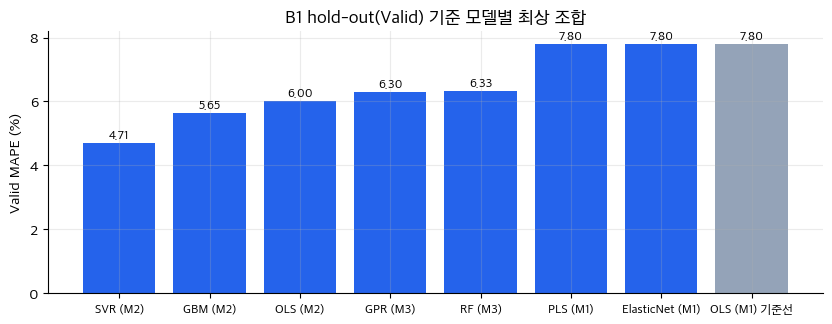

In [6]:
# Valid 20회 반복 (B1 안에서 같은 충전방식끼리 묶은 hold-out을 20번 다르게 나눔 — 선택의 안정성 확인)
gss = GroupShuffleSplit(n_splits=20, test_size=0.2, random_state=1); rep = []
for _, r in R.iterrows():
    make, F, params = MODELS[r.model][0], FSETS[r.fset], json.loads(r.params)
    e = [mape(B1.log_life.values[b], fit_pred(make, params, B1[F].values[a], B1.log_life.values[a], B1[F].values[b])) for a, b in gss.split(B1, groups=B1.group)]
    rep.append((np.mean(e), np.std(e)))
R['rep_mean'], R['rep_sd'] = zip(*rep)

best_per_model = R.loc[lambda d: d.groupby('model').valid.idxmin()].sort_values('valid')
base = R[(R.model == 'OLS') & (R.fset == 'M1')]
show = pd.concat([best_per_model, base])
print('[모델마다 M1·M2·M3 중 B1 Valid 최상 조합 + OLS(M1) 기준선]')
display(show[['model', 'fset', 'train_cv', 'valid', 'rep_mean', 'rep_sd', 'test_b2', 'test_b3']].round(2).reset_index(drop=True))

fig, ax = plt.subplots(figsize=(10, 3.4)); lab = [f'{m} ({f})' for m, f in zip(best_per_model.model, best_per_model.fset)] + ['OLS (M1) 기준선']
vals = list(best_per_model.valid) + list(base.valid); ax.bar(range(len(vals)), vals, color=['#2563eb'] * len(best_per_model) + ['#94a3b8'])
for i, v in enumerate(vals): ax.text(i, v + .15, f'{v:.2f}', ha='center', fontsize=9)
ax.set_xticks(range(len(vals))); ax.set_xticklabels(lab, fontsize=9); ax.set_ylabel('Valid MAPE (%)'); ax.set_title('B1 hold-out(Valid) 기준 모델별 최상 조합'); plt.show()

낮을수록 좋은 것. (MAPE: 예측 수명이 실제 수명에서 평균 몇 % 벗어났는지. Train · Valid · Test 모두 같음)

In [7]:
print('[전체 학습 조합 — Valid 오름차순]')
display(R.sort_values('valid')[['model', 'fset', 'params', 'train_cv', 'valid', 'rep_mean', 'test_b2', 'test_b3']].round(2).reset_index(drop=True))

[전체 학습 조합 — Valid 오름차순]


,model,fset,params,train_cv,valid,rep_mean,test_b2,test_b3
0,SVR,M2,"{""C"": 10, ""gamma"": 0.01, ""epsilon"": 0.01}",8.19,4.71,6.90,31.45,12.45
1,GBM,M2,"{""n_estimators"": 100, ""learning_rate"": 0.03, ""...",10.69,5.65,8.77,35.10,21.33
2,OLS,M2,{},8.64,6.00,7.05,39.35,12.97
3,GPR,M3,{},10.34,6.30,8.01,41.03,17.24
4,RF,M3,"{""max_depth"": 3, ""min_samples_leaf"": 1}",10.22,6.33,9.47,33.85,18.46
5,RF,M2,"{""max_depth"": 3, ""min_samples_leaf"": 1}",10.36,6.55,8.83,34.23,18.26
6,GBM,M3,"{""n_estimators"": 100, ""learning_rate"": 0.03, ""...",11.01,6.59,8.71,38.30,18.01
7,OLS,M3,{},7.96,6.70,7.30,41.41,11.98
8,GPR,M2,{},10.89,6.72,7.61,40.79,15.04
9,RF,M1,"{""max_depth"": 2, ""min_samples_leaf"": 1}",10.29,7.10,10.09,29.20,15.64


MAPE는 낮을수록 좋음. 최종 모델은 Valid(B1 hold-out)가 가장 낮은 조합으로 선택하고, Test(B2·B3)는 선택에 쓰지 않음.

## 3. 최종 모델 · 성능 (Notion Reporting format)

In [8]:
final = best_per_model.iloc[0]; key = (final.model, final.fset); params, p2, p3 = store[key]       # 선택 기준: B1 Valid 1위 (Test는 사용 안 함)
print(f'최종 모델: {final.model} ({final.fset}) {final.params}')
b3_wo = B3.index != 'B3c37'                                                                       # 노이즈가 큰 셀 제외 시
perf = pd.DataFrame([
    ['Train (Batch 1 CV)', final.train_cv, '같은 충전방식끼리 묶은 5-fold CV 평균'],
    ['Valid (Batch 1 Hold-out)', final.valid, f'B1 {len(B1ho)}셀(충전방식 {B1ho.group.nunique()}개) hold-out'],
    ['Test (Batch 2)', final.test_b2, 'B1 전체 재학습 후 1회 평가'],
    ['Gap (Train-Valid)', final.valid - final.train_cv, '(+) : 과적합 의심'],
    ['Gap (Valid-Test)', final.test_b2 - final.valid, '(+) : 배치간 일반화 저하 의심'],
    ['Gap (Target-Test)', final.test_b2 - TARGET_PAPER, 'Target : 원논문 9.1%'],
    ['Test (Batch 3)', final.test_b3, f'B3c37(노이즈 셀) 제외 시 {mape(B3.log_life.values[b3_wo], p3[b3_wo]):.2f}'],
    ['Gap (Batch2-Batch3)', final.test_b2 - final.test_b3, 'Test 성능 간 비교'],
    ['Gap (Target-Test B3)', final.test_b3 - TARGET_PAPER, 'Batch 3 기준, 원논문 성능 비교'],
], columns=['구분', 'MAPE (%)', '비고']); perf['MAPE (%)'] = perf['MAPE (%)'].round(2)
display(perf)
print('RMSE(사이클 수): B2', round(np.sqrt(np.mean((10 ** p2 - B2.cycle_life.values) ** 2))), '· B3', round(np.sqrt(np.mean((10 ** p3 - B3.cycle_life.values) ** 2))))
R.to_csv(os.path.join(RESULT_DIR, 'model_comparison.csv'), index=False); perf.to_csv(os.path.join(RESULT_DIR, 'model_performance.csv'), index=False)

최종 모델: SVR (M2) {"C": 10, "gamma": 0.01, "epsilon": 0.01}


,구분,MAPE (%),비고
0,Train (Batch 1 CV),8.19,같은 충전방식끼리 묶은 5-fold CV 평균
1,Valid (Batch 1 Hold-out),4.71,B1 7셀(충전방식 4개) hold-out
2,Test (Batch 2),31.45,B1 전체 재학습 후 1회 평가
3,Gap (Train-Valid),-3.48,(+) : 과적합 의심
4,Gap (Valid-Test),26.74,(+) : 배치간 일반화 저하 의심
5,Gap (Target-Test),22.35,Target : 원논문 9.1%
6,Test (Batch 3),12.45,B3c37(노이즈 셀) 제외 시 12.32
7,Gap (Batch2-Batch3),19.00,Test 성능 간 비교
8,Gap (Target-Test B3),3.35,"Batch 3 기준, 원논문 성능 비교"


RMSE(사이클 수): B2 200 · B3 245


Train · Valid · Test: MAPE, 낮을수록 좋음.  
Gap = 뒤 단계 MAPE − 앞 단계 MAPE → (+)이면 뒤 단계에서 더 틀림(Train−Valid: 과적합 의심, Valid−Test: 배치 간 일반화 저하 의심), 0 또는 (−)이면 문제 없음.  
Gap (Target−Test)는 원논문 9.1%와의 차이 → (+)이면 원논문보다 나쁨, (−)이면 원논문보다 좋음.

## 4. 피처 세트 비교 (SVR 기준) · 선형성

In [9]:
sv = R[R.model == 'SVR'].set_index('fset').loc[['M1', 'M2', 'M3']]
display(sv[['train_cv', 'valid', 'rep_mean', 'rep_sd', 'test_b2', 'test_b3']].round(2))

# 최종 SVR 예측이 같은 피처의 직선식으로 얼마나 설명되는가
F = FSETS[final.fset]; allc = pd.concat([B1, B2, B3])
svr = MODELS['SVR'][0](**params).fit(B1[F].values, B1.log_life.values); ps = svr.predict(allc[F].values)
lin = LinearRegression().fit(allc[F].values, ps)
dev = pd.Series(100 * np.abs(10 ** lin.predict(allc[F].values) - 10 ** ps) / 10 ** ps, index=allc.index)
print(f'SVR 예측을 직선식으로 근사 R² = {lin.score(allc[F].values, ps):.3f} (119셀) · 10% 이내 {int((dev <= 10).sum())}/{len(dev)}셀, 중앙값 {dev.median():.1f}%')
x, y = B1.dq_var.values, B1.log_life.values
for deg in (1, 2):
    c_ = np.polyfit(x, y, deg); print(f'B1 log Var ΔQ–log 수명 {deg}차식 R² = {1 - ((y - np.polyval(c_, x)) ** 2).sum() / ((y - y.mean()) ** 2).sum():.3f}')
kind = {'OLS': '선형', 'ElasticNet': '선형', 'PLS': '선형', 'SVR': '거의 선형(RBF, gamma 작음)', 'GPR': '비선형', 'RF': '비선형', 'GBM': '비선형'}
M2t = R[R.fset == 'M2'].set_index('model').loc[list(kind)]
display(M2t.assign(유형=pd.Series(kind))[['유형', 'rep_mean', 'test_b2', 'test_b3']].round(2))

,train_cv,valid,rep_mean,rep_sd,test_b2,test_b3
fset,,,,,,
M1,9.62,8.73,10.40,2.08,30.55,11.93
M2,8.19,4.71,6.90,1.54,31.45,12.45
M3,8.27,7.12,7.62,1.63,45.00,19.13


SVR 예측을 직선식으로 근사 R² = 0.946 (119셀) · 10% 이내 113/119셀, 중앙값 3.0%
B1 log Var ΔQ–log 수명 1차식 R² = 0.712
B1 log Var ΔQ–log 수명 2차식 R² = 0.719


,유형,rep_mean,test_b2,test_b3
model,,,,
OLS,선형,7.05,39.35,12.97
ElasticNet,선형,8.32,44.12,13.45
PLS,선형,8.20,56.11,21.01
SVR,"거의 선형(RBF, gamma 작음)",6.90,31.45,12.45
GPR,비선형,7.61,40.79,15.04
RF,비선형,8.83,34.23,18.26
GBM,비선형,8.77,35.10,21.33


MAPE는 낮을수록 좋음 (rep_mean = B1 hold-out 20회 반복 평균).  
R² = 직선식이 SVR 예측을 얼마나 설명하는지, 1에 가까울수록(높을수록) SVR이 직선에 가깝다는 뜻.

## 5. 오류 분석

,MAPE,평균부호오차,셀수
구간,,,
B1보다 짧음(<534),31.7,31.4,30
B1 범위(534~1074),13.4,3.5,35
B1보다 김(>1074),19.7,-19.7,18


B2 구조별 MAPE: {'기존 구조': 31.7, 'newstructure': 30.5} | B2 평균 부호오차 +30.5%, 길게 예측한 셀 92%

[B2] 가장 크게 틀린 셀


,life,pred,b,policy,newstruct,err%,구간
cell,,,,,,,
B2c9,791.0,1341.4,B2,5.6C(26%)-4.5C-newstructure,1,69.6,B1 범위(534~1074)
B2c44,841.0,1358.5,B2,5.2C(58%)-4C-newstructure,1,61.5,B1 범위(534~1074)
B2c6,393.0,593.4,B2,3.6C(9%)-5C,0,51.0,B1보다 짧음(<534)
B2c0,477.0,693.3,B2,5.2C(58%)-4C,0,45.3,B1보다 짧음(<534)



[B3] 가장 크게 틀린 셀


,life,pred,b,policy,newstruct,err%,구간
cell,,,,,,,
B3c38,1935.0,1068.0,B3,5C(67%)-4C-newstructure,1,-44.8,B1보다 김(>1074)
B3c7,1836.0,1186.1,B3,4.8C(80%)-4.8C-newstructure,1,-35.4,B1보다 김(>1074)
B3c42,1642.0,1071.3,B3,4.8C(80%)-4.8C-newstructure,1,-34.8,B1보다 김(>1074)
B3c45,1801.0,1249.4,B3,4.8C(80%)-4.8C-newstructure,1,-30.6,B1보다 김(>1074)



B2를 550 cycle 기준으로 판정: 회귀 예측 사용 정확도 41% (단수명 30셀 중 7셀 맞힘) · B1 장수명 35 : 단수명 1라 분류기는 사실상 전부 장수명만 학습 → 정확도 23%


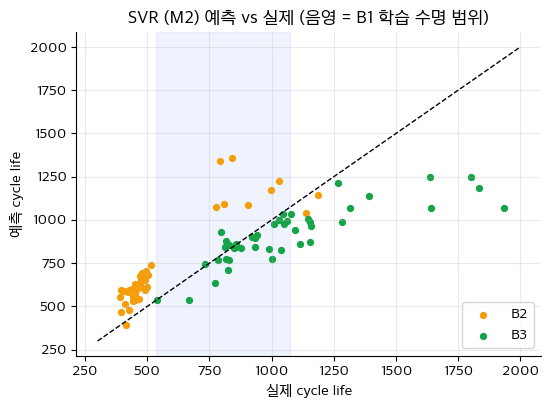

In [10]:
allp = pd.concat([pd.DataFrame({'life': B2.cycle_life, 'pred': 10 ** p2, 'b': 'B2', 'policy': B2.policy, 'newstruct': B2.newstruct}),
                  pd.DataFrame({'life': B3.cycle_life, 'pred': 10 ** p3, 'b': 'B3', 'policy': B3.policy, 'newstruct': B3.newstruct})])
allp['err%'] = 100 * (allp.pred - allp.life) / allp.life
lo, hi = B1.cycle_life.min(), B1.cycle_life.max()
allp['구간'] = pd.cut(allp.life, [0, lo, hi, 3000], labels=[f'B1보다 짧음(<{lo:.0f})', f'B1 범위({lo:.0f}~{hi:.0f})', f'B1보다 김(>{hi:.0f})'])
display(allp.groupby('구간', observed=True)['err%'].agg(MAPE=lambda s: s.abs().mean(), 평균부호오차='mean', 셀수='size').round(1))
b2 = allp[allp.b == 'B2']
print('B2 구조별 MAPE:', b2.groupby('newstruct')['err%'].apply(lambda s: s.abs().mean()).round(1).rename({0: '기존 구조', 1: 'newstructure'}).to_dict(),
      '| B2 평균 부호오차 %+.1f%%, 길게 예측한 셀 %.0f%%' % (b2['err%'].mean(), 100 * (b2['err%'] > 0).mean()))
for b in ('B2', 'B3'):
    d = allp[allp.b == b]; print(f'\n[{b}] 가장 크게 틀린 셀'); display(d.reindex(d['err%'].abs().sort_values(ascending=False).index).head(4).round(1))
# 550 cycle 기준 장/단수명 판정 (분류로 풀었을 때와 비교)
yb = (b2.life >= 550).astype(int); pb = (b2.pred >= 550).astype(int)
print(f'\nB2를 550 cycle 기준으로 판정: 회귀 예측 사용 정확도 {100 * (yb == pb).mean():.0f}% (단수명 {int((yb == 0).sum())}셀 중 {int(((yb == 0) & (pb == 0)).sum())}셀 맞힘) · '
      f'B1 장수명 {int((B1.cycle_life >= 550).sum())} : 단수명 {int((B1.cycle_life < 550).sum())}라 분류기는 사실상 전부 장수명만 학습 → 정확도 {100 * (yb == 1).mean():.0f}%')
fig, ax = plt.subplots(figsize=(6, 4.2)); ax.axvspan(lo, hi, color='#2563eb', alpha=.07)
for b, col in (('B2', '#f59e0b'), ('B3', '#16a34a')): g = allp[allp.b == b]; ax.scatter(g.life, g.pred, s=18, color=col, label=b)
ax.plot([300, 2000], [300, 2000], 'k--', lw=1); ax.set_xlabel('실제 cycle life'); ax.set_ylabel('예측 cycle life'); ax.legend(); ax.set_title(f'{final.model} ({final.fset}) 예측 vs 실제 (음영 = B1 학습 수명 범위)'); plt.show()

MAPE는 낮을수록 좋음.  
오차(err%) 부호: (+) = 실제보다 길게 예측, (−) = 짧게 예측. 평균부호오차가 0에 가까울수록 한쪽으로 치우치지 않음.  
점이 점선(y = x)에 가까울수록 정확. 판정 정확도는 높을수록 좋음.

## 6. 과적합 점검 (B1만 학습)

In [11]:
make = MODELS[final.model][0]; F = FSETS[final.fset]; Xtr, ytr = B1tr[F].values, B1tr.log_life.values
m_tr = make(**params).fit(Xtr, ytr)
print(f'학습 셀 {mape(ytr, m_tr.predict(Xtr)):.1f}% · 교차검증 {final.train_cv:.1f}% · hold-out {final.valid:.1f}% · hold-out 20회 반복 {final.rep_mean:.1f} ± {final.rep_sd:.1f}%')
rng = np.random.default_rng(0); curve = {}
for n in [8, 12, 16, 20, 24, 28]:            # 학습 곡선: 학습 셀 수를 늘리며 학습·검증 오차 간격 확인
    trs, vas = [], []
    for _ in range(6):
        Bp = B1.iloc[rng.permutation(len(B1))]
        for a, b in gkf.split(Bp, groups=Bp.group):
            a = a[:n]
            if len(a) < n: continue
            mm = make(**params).fit(Bp.iloc[a][F].values, Bp.iloc[a].log_life.values)
            trs.append(mape(Bp.iloc[a].log_life.values, mm.predict(Bp.iloc[a][F].values))); vas.append(mape(Bp.iloc[b].log_life.values, mm.predict(Bp.iloc[b][F].values)))
    curve[n] = (np.mean(trs), np.mean(vas))
cv_df = pd.DataFrame(curve, index=['학습 오차', '검증 오차']).T.assign(간격=lambda d: d['검증 오차'] - d['학습 오차']); cv_df.index.name = '학습 셀 수'; display(cv_df.round(2))
reg = []
for Cv in [0.1, 0.3, 1, 3, 10, 30, 100]:     # SVR 규제 강도 C 변경
    p_ = dict(params); p_['C'] = Cv; mm = make(**p_).fit(B1[F].values, B1.log_life.values)
    cvv = np.mean([mape(ytr[b], fit_pred(make, p_, Xtr[a], ytr[a], Xtr[b])) for a, b in gkf.split(Xtr, ytr, B1tr.group.values)])
    reg.append(dict(C=Cv, B1_CV=cvv, Test_B2=mape(B2.log_life.values, mm.predict(B2[F].values)), Test_B3=mape(B3.log_life.values, mm.predict(B3[F].values))))
display(pd.DataFrame(reg).round(2))
mo = LinearRegression().fit(B1[['dq_var']].values, B1.log_life.values)
print(f"가장 단순한 모델(OLS, 피처 1개): B1 {mape(B1.log_life.values, mo.predict(B1[['dq_var']].values)):.1f}% · B2 {mape(B2.log_life.values, mo.predict(B2[['dq_var']].values)):.1f}% · B3 {mape(B3.log_life.values, mo.predict(B3[['dq_var']].values)):.1f}%")
print(f"B2 예측 순위 상관(Spearman) {stats.spearmanr(p2, B2.cycle_life.values)[0]:.2f} · 길게 치우친 정도 {b2['err%'].mean():+.1f}% → 무작위 과적합이 아니라 한쪽으로 치우친 배치 이동")

학습 셀 5.1% · 교차검증 8.2% · hold-out 4.7% · hold-out 20회 반복 6.9 ± 1.5%


,학습 오차,검증 오차,간격
학습 셀 수,,,
8,2.74,10.76,8.02
12,3.38,10.11,6.74
16,3.94,9.19,5.25
20,4.07,7.77,3.70
24,4.45,7.84,3.39
28,4.61,7.55,2.94


,C,B1_CV,Test_B2,Test_B3
0,0.1,12.05,54.90,22.41
1,0.3,10.68,47.38,18.37
2,1.0,10.00,35.17,14.02
3,3.0,8.79,33.20,11.51
4,10.0,8.19,31.45,12.45
5,30.0,9.12,24.92,15.59
6,100.0,10.41,19.24,20.68


가장 단순한 모델(OLS, 피처 1개): B1 8.2% · B2 28.6% · B3 12.8%
B2 예측 순위 상관(Spearman) 0.89 · 길게 치우친 정도 +30.5% → 무작위 과적합이 아니라 한쪽으로 치우친 배치 이동


오차(MAPE, 학습 오차 · 검증 오차)는 낮을수록 좋음.  
학습 곡선의 간격(검증 − 학습)이 작을수록, 학습 셀이 늘어날수록 간격이 줄어들수록 과적합이 약함.  
Spearman 순위 상관은 1에 가까울수록(높을수록) 셀 사이의 수명 순서를 잘 맞힘.

## 7. 원논문 분할 방식 재현 · 평가 방식별 모델 비교

In [12]:
# 원논문 코드(LoadData.m)의 분할: 배치를 이어 붙인 목록에서 번갈아 테스트로 분리 → 우리 전처리 후 데이터로 재현
order = lambda df: df.loc[sorted(df.index, key=lambda c: int(c.split('c')[1]))]
def mixed(model, fset, other):
    r = R[(R.model == model) & (R.fset == fset)].iloc[0]; mk, Ff, pr = MODELS[model][0], FSETS[fset], json.loads(r.params)
    comb = pd.concat([order(B1), order(other)]); n = len(comb)
    te_i = np.unique(np.r_[np.arange(0, n, 2), n - 1]); tr_i = np.setdiff1d(np.arange(n), te_i); tr, te = comb.iloc[tr_i], comb.iloc[te_i]
    return mape(te.log_life.values, fit_pred(mk, pr, tr[Ff].values, tr.log_life.values, te[Ff].values)), len(tr), len(te)
for nm, oth in (('B2', B2), ('B3', B3)):
    m, ntr, nte = mixed(final.model, final.fset, oth); print(f'{final.model}({final.fset}) 원논문 분할 B1+{nm}: 학습 {ntr}셀 / 테스트 {nte}셀 → MAPE {m:.2f}%')
sel = [('OLS', 'M1'), ('OLS', 'M2'), ('ElasticNet', 'M2'), ('PLS', 'M2'), ('SVR', 'M2'), ('GPR', 'M2'), ('RF', 'M2'), ('GBM', 'M2')]
rows = []
for m, f in sel:
    r = R[(R.model == m) & (R.fset == f)].iloc[0]
    rows.append({'모델': f'{m} ({f})' + (' 기준선' if (m, f) == ('OLS', 'M1') else ''), 'B1 검증(20회 반복)': r.rep_mean, 'Notion Test B2': r.test_b2, 'Notion Test B3': r.test_b3,
                 '원논문 분할 B1+B2': mixed(m, f, B2)[0], '원논문 분할 B1+B3': mixed(m, f, B3)[0]})
CMP = pd.DataFrame(rows).set_index('모델'); CMP['1위 횟수'] = (CMP.iloc[:, :5] == CMP.iloc[:, :5].min()).sum(axis=1)
display(CMP.round(2)); CMP.to_csv(os.path.join(RESULT_DIR, 'evaluation_protocol_comparison.csv'))
print('SVR(M2)의 5개 평가 순위:', CMP.iloc[:, :5].rank(method='min').loc['SVR (M2)'].astype(int).tolist())

SVR(M2) 원논문 분할 B1+B2: 학습 37셀 / 테스트 38셀 → MAPE 9.98%
SVR(M2) 원논문 분할 B1+B3: 학습 39셀 / 테스트 41셀 → MAPE 9.48%


,B1 검증(20회 반복),Notion Test B2,Notion Test B3,원논문 분할 B1+B2,원논문 분할 B1+B3,1위 횟수
모델,,,,,,
OLS (M1) 기준선,10.39,28.56,12.81,14.41,10.95,1
OLS (M2),7.05,39.35,12.97,11.86,9.20,1
ElasticNet (M2),8.32,44.12,13.45,11.95,10.50,0
PLS (M2),8.20,56.11,21.01,12.11,11.60,0
SVR (M2),6.90,31.45,12.45,9.98,9.48,3
GPR (M2),7.61,40.79,15.04,15.05,9.80,0
RF (M2),8.83,34.23,18.26,11.12,11.00,0
GBM (M2),8.77,35.10,21.33,10.76,10.14,0


SVR(M2)의 5개 평가 순위: [1, 2, 1, 1, 2]


MAPE는 낮을수록 좋음. 1위 횟수는 5개 평가 중 해당 모델이 가장 낮았던 횟수 → 많을수록 좋음. 순위는 1이 가장 좋음.